# Phoenix Dataset — Feature Extraction
Uses the original `FeatureEngineer.run()` pipeline unchanged.

**Setup:** Place this notebook in the same folder as:
`feature_engineer.py`, `data_cleaning_pipeline.py`, `config.yaml`, and `phoenix_combined_dataset_large.xlsx`

**Workflow**
1. Load Phoenix dataset
2. Map Phoenix columns → required schema
3. Call `fe.run()` — handles cleaning, feature engineering, validation and saving


In [19]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Notebook directory — works on any machine without hardcoded paths.
# All project files must sit in the same folder as this notebook.
try:
    PROJECT_DIR = Path(__vsc_ipynb_file__).parent  # VS Code
except NameError:
    PROJECT_DIR = Path().resolve()                 # JupyterLab / classic

sys.path.insert(0, str(PROJECT_DIR))
from feature_engineer import FeatureEngineer

print(f'Project dir : {PROJECT_DIR}')
print('Imports OK')


Project dir : c:\Users\sjbra\Documents\Phoenix\ai-ml\features
Imports OK


## 1 · Configuration

In [20]:
DATASET_NAME = 'phoenix_combined_dataset_large.xlsx'
INPUT_PATH   = PROJECT_DIR / DATASET_NAME

# Phoenix hazard_severity strings → numeric values
SEVERITY_MAP = {'low': 2, 'medium': 5, 'high': 7, 'critical': 9}
DURATION_MAP = {'low': 2, 'medium': 5, 'high': 8, 'critical': 12}

print(f'Dataset path : {INPUT_PATH}')
print(f'File exists  : {INPUT_PATH.exists()}')


Dataset path : c:\Users\sjbra\Documents\Phoenix\ai-ml\features\phoenix_combined_dataset_large.xlsx
File exists  : True


## 2 · Load Raw Phoenix Data

In [21]:
raw = pd.read_excel(INPUT_PATH)
print(f'Shape   : {raw.shape}')
print(f'Columns : {raw.columns.tolist()}')
raw.head(3)


Shape   : (2000, 10)
Columns : ['url', 'text', 'timestamp', 'hazard_type', 'hazard_severity', 'hazard_timestamp', 'hazard_location', 'hazard_status', 'alert_level', 'source']


,url,text,timestamp,hazard_type,hazard_severity,hazard_timestamp,hazard_location,hazard_status,alert_level,source
0,https://twitter.com/status/928374650192,Hoax: Power company secretly rationing electri...,"August 09, 2019",misinformation,low,"August 09, 2019",France,pending,low,Social Media Disaster Tweets Dataset
1,https://reddit.com/r/conspiracy/abc123,Fabricated: Mayor orders mandatory evacuation ...,"January 03, 2021",misinformation,low,"January 03, 2021","Georgia, USA",resolved,low,Claim Fraud Detection Dataset
2,https://www.fs.usda.gov/managing-land/fire,NASA FIRMS: Grassland fire sweeping through Mi...,"July 17, 2022",wildfire,medium,"July 18, 2022","Catalonia, Spain",pending,high,USDA Forest Service


## 3 · Map Phoenix Columns → FeatureEngineer Schema
The original `FeatureEngineer` expects:
`severity`, `cyber_incidents`, `timestamp`, `location`, `duration_hours`

We derive these from the Phoenix columns below.


In [22]:
df = raw.copy()

# severity: ordinal from hazard_severity string
df['severity'] = (
    df['hazard_severity'].str.lower().str.strip()
    .map(SEVERITY_MAP).fillna(5).astype(float)
)

# duration_hours: proxy from hazard_severity
df['duration_hours'] = (
    df['hazard_severity'].str.lower().str.strip()
    .map(DURATION_MAP).fillna(5).astype(float)
)

# location: first part of hazard_location
df['location'] = (
    df['hazard_location'].fillna('Unknown')
    .str.split(',').str[0].str.strip().str.title()
)

# cyber_incidents: count of cyber_threat rows per location as proxy
cyber_counts = (
    df[df['hazard_type'] == 'cyber_threat']
    .groupby('location').size().rename('cyber_incidents')
)
df = df.join(cyber_counts, on='location')
df['cyber_incidents'] = df['cyber_incidents'].fillna(1).astype(float)

# timestamp: parse the report timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%B %d, %Y', errors='coerce')

print('Mapped schema:')
print(df[['severity', 'duration_hours', 'location', 'cyber_incidents', 'timestamp']].dtypes)
print(f'\nNull counts:')
print(df[['severity', 'duration_hours', 'location', 'cyber_incidents', 'timestamp']].isnull().sum())
df[['severity', 'duration_hours', 'location', 'cyber_incidents', 'timestamp']].head(5)


Mapped schema:
severity                  float64
duration_hours            float64
location                   object
cyber_incidents           float64
timestamp          datetime64[us]
dtype: object

Null counts:
severity           0
duration_hours     0
location           0
cyber_incidents    0
timestamp          0
dtype: int64


,severity,duration_hours,location,cyber_incidents,timestamp
0,2.0,2.0,France,1.0,2019-08-09
1,2.0,2.0,Georgia,4.0,2021-01-03
2,5.0,5.0,Catalonia,1.0,2022-07-17
3,9.0,12.0,Nigeria,1.0,2021-05-27
4,9.0,12.0,Southern Ontario,1.0,2017-10-23


## 4 · Prepare Input DataFrame

In [23]:
required_cols = ['timestamp', 'location', 'severity', 'duration_hours', 'cyber_incidents']
fe_input = df[required_cols].copy()

print(f'Input shape: {fe_input.shape}')
fe_input.head(3)


Input shape: (2000, 5)


,timestamp,location,severity,duration_hours,cyber_incidents
0,2019-08-09,France,2.0,2.0,1.0
1,2021-01-03,Georgia,2.0,2.0,4.0
2,2022-07-17,Catalonia,5.0,5.0,1.0


## 5 · Run Feature Engineering Pipeline
Calls `fe.run()` which internally:
- Loads `config.yaml` if present in the project folder
- Runs `run_cleaning_pipeline()`
- Runs all feature groups: hazard, cyber, temporal, geo, risk, anomaly
- Validates output
- Saves `ai004_features_output.csv` and `feature_mapping.json` to the project folder


In [24]:
import feature_engineer
print(feature_engineer.__file__)
fe = FeatureEngineer(fe_input)
result = fe.run()

print(f'\nOutput shape : {result.shape}')
print(f'Columns ({len(result.columns)}) : {result.columns.tolist()}')


2026-05-15 11:38:59,339 - INFO - Running validation checks...
2026-05-15 11:38:59,343 - INFO - Validation passed. Shape: (1996, 32)


c:\Users\sjbra\Documents\Phoenix\ai-ml\features\feature_engineer.py

Data Quality Score: 90.00/100

 PIPELINE COMPLETED SUCCESSFULLY
{'hazard_features': 6, 'cyber_features': 8, 'temporal_features': 6, 'geo_features': 3, 'risk_features': 3, 'anomaly_features': 2}

Output shape : (1996, 32)
Columns (32) : ['timestamp', 'location', 'severity', 'duration_hours', 'cyber_incidents', 'disaster_severity_score', 'event_intensity_index', 'hazard_normalized', 'severity_change_rate', 'hazard_trend_index', 'severity_volatility', 'multi_event_overlap_flag', 'cyber_incident_count', 'cyber_intensity_score', 'scam_spike_rate', 'cyber_attack_frequency', 'cyber_growth_rate', 'cyber_volatility', 'incident_peak_flag', 'rolling_cyber_mean', 'time_since_last_event', 'ema', 'lag_1', 'lag_2', 'time_decay_factor', 'geo_risk_zone_score', 'location_encoded', 'regional_event_count', 'combined_risk_index', 'adaptive_risk_index', 'z_score', 'outlier_flag']


## 6 · Inspect Output

In [25]:
result.head(5)


,timestamp,location,severity,duration_hours,cyber_incidents,disaster_severity_score,event_intensity_index,hazard_normalized,severity_change_rate,hazard_trend_index,...,lag_1,lag_2,time_decay_factor,geo_risk_zone_score,location_encoded,regional_event_count,combined_risk_index,adaptive_risk_index,z_score,outlier_flag
838,2016-01-01,Phoenix,7.0,8.0,1.0,10.5,56.0,0.777778,2.0,7.000000,...,0.0,0.0,1.000000,0.5,111,17,7.0,3.500000,-1.212850,0
277,2016-01-03,Black forest,9.0,12.0,1.0,13.5,108.0,1.000000,2.0,8.333333,...,1.0,0.0,0.904837,1.0,20,7,9.0,4.500000,-1.212850,0
823,2016-01-03,Amazon basin,5.0,5.0,3.0,7.5,25.0,0.555555,0.0,5.666667,...,1.0,1.0,0.818731,0.5,8,20,15.0,5.625000,-0.040242,0
1463,2016-01-05,Victoria,5.0,5.0,3.0,7.5,25.0,0.555555,-4.0,7.666667,...,3.0,1.0,0.740818,0.5,151,23,15.0,4.500000,-0.040242,0
125,2016-01-10,Gulf of mexico,9.0,12.0,2.0,13.5,108.0,1.000000,4.0,7.000000,...,3.0,3.0,0.670320,1.0,51,21,18.0,4.909091,-0.626546,0


## 7 · Feature Summary Statistics

In [26]:
feature_cols = [
    'disaster_severity_score', 'event_intensity_index', 'hazard_normalized',
    'severity_change_rate', 'hazard_trend_index', 'severity_volatility',
    'multi_event_overlap_flag',
    'cyber_incident_count', 'cyber_intensity_score', 'scam_spike_rate',
    'cyber_attack_frequency', 'cyber_growth_rate', 'cyber_volatility',
    'incident_peak_flag',
    'rolling_cyber_mean', 'time_since_last_event', 'ema', 'lag_1', 'lag_2',
    'time_decay_factor',
    'geo_risk_zone_score', 'location_encoded', 'regional_event_count',
    'combined_risk_index', 'adaptive_risk_index',
    'z_score', 'outlier_flag',
]
available = [c for c in feature_cols if c in result.columns]

summary = result[available].describe().T.round(4)
summary['missing']     = result[available].isnull().sum()
summary['missing_pct'] = (summary['missing'] / len(result) * 100).round(2)
summary


,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
disaster_severity_score,1996.0,9.4509,3.5658,3.0000,7.5000,10.5000,13.5000,13.5000,0,0.0
event_intensity_index,1996.0,55.4429,38.5598,4.0000,25.0000,56.0000,108.0000,108.0000,0,0.0
hazard_normalized,1996.0,0.7001,0.2641,0.2222,0.5556,0.7778,1.0000,1.0000,0,0.0
severity_change_rate,1996.0,0.0000,3.3585,-7.0000,-2.0000,0.0000,2.0000,7.0000,0,0.0
hazard_trend_index,1996.0,6.2994,1.3614,2.0000,5.3333,6.3333,7.0000,9.0000,0,0.0
severity_volatility,1996.0,2.1187,1.0989,0.0000,1.1547,2.0000,2.8868,4.0415,0,0.0
multi_event_overlap_flag,1996.0,0.3011,0.4589,0.0000,0.0000,0.0000,1.0000,1.0000,0,0.0
cyber_incident_count,1996.0,3.0686,1.7056,1.0000,1.0000,3.0000,4.0000,7.0000,0,0.0
cyber_intensity_score,1996.0,0.4384,0.2437,0.1429,0.1429,0.4286,0.5714,1.0000,0,0.0
scam_spike_rate,1996.0,0.0015,2.3920,-6.0000,-2.0000,0.0000,2.0000,6.0000,0,0.0


## 8 · Feature Distributions

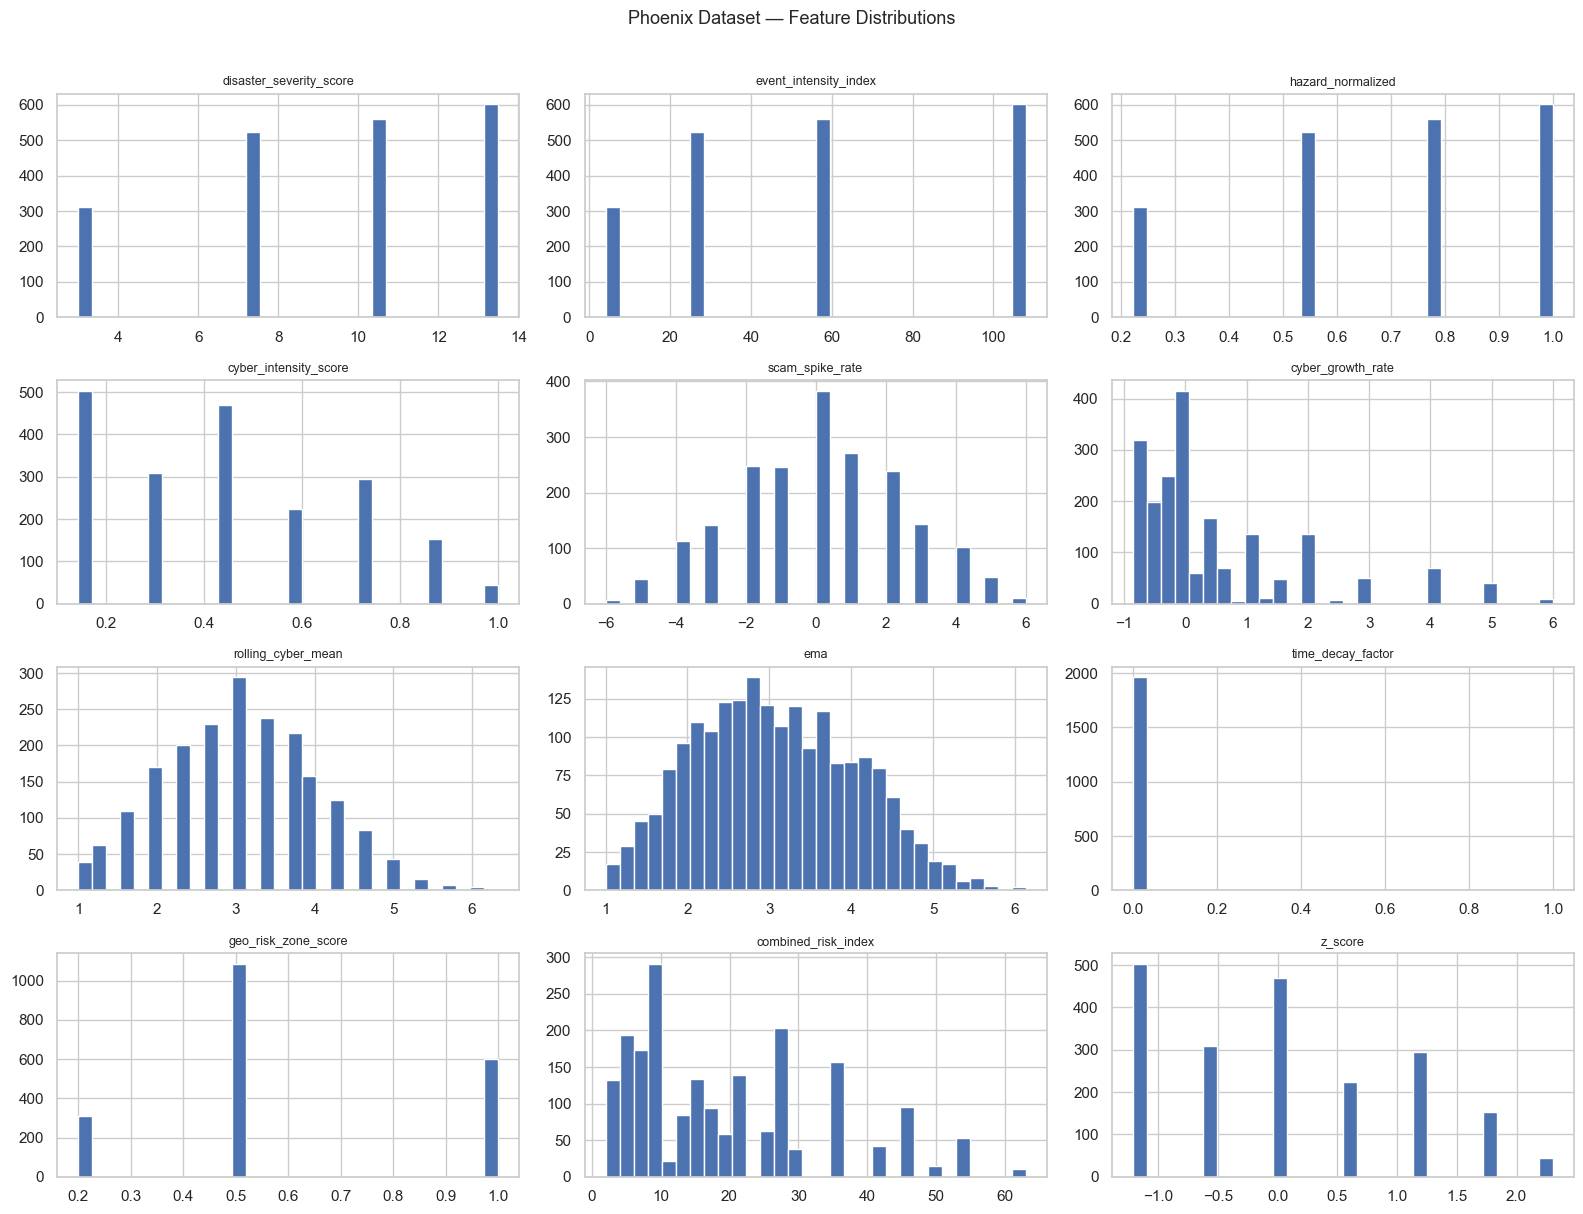

Saved: feature_distributions.png


In [27]:
plot_cols = [
    'disaster_severity_score', 'event_intensity_index', 'hazard_normalized',
    'cyber_intensity_score', 'scam_spike_rate', 'cyber_growth_rate',
    'rolling_cyber_mean', 'ema', 'time_decay_factor',
    'geo_risk_zone_score', 'combined_risk_index', 'z_score',
]
plot_cols = [c for c in plot_cols if c in result.columns]

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), plot_cols):
    result[col].dropna().hist(ax=ax, bins=30, color='#4C72B0', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
for ax in axes.flatten()[len(plot_cols):]:
    ax.set_visible(False)

plt.suptitle('Phoenix Dataset — Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')


## 9 · Risk Index by Hazard Type

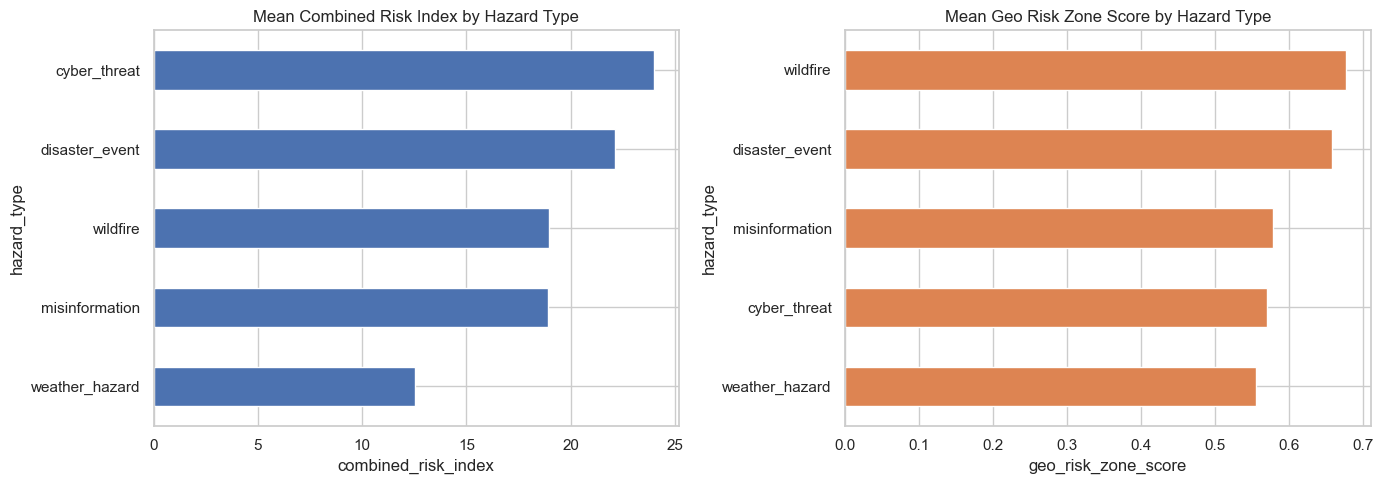

In [28]:
# Re-attach hazard_type from raw for grouping
result_labelled = result.copy()
result_labelled['hazard_type'] = raw['hazard_type'].reindex(result_labelled.index).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

result_labelled.groupby('hazard_type')['combined_risk_index'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='#4C72B0'
)
axes[0].set_title('Mean Combined Risk Index by Hazard Type')
axes[0].set_xlabel('combined_risk_index')

result_labelled.groupby('hazard_type')['geo_risk_zone_score'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='#DD8452'
)
axes[1].set_title('Mean Geo Risk Zone Score by Hazard Type')
axes[1].set_xlabel('geo_risk_zone_score')

plt.tight_layout()
plt.savefig(PROJECT_DIR / 'risk_by_hazard_type.png', dpi=120, bbox_inches='tight')
plt.show()


## 10 · Outlier & Anomaly Summary

In [29]:
n_outliers = result['outlier_flag'].sum()
n_peaks    = result['incident_peak_flag'].sum()
n_overlap  = result['multi_event_overlap_flag'].sum()

print(f'Outliers (|z| > 2)       : {n_outliers} ({n_outliers/len(result)*100:.1f}%)')
print(f'Cyber incident peaks     : {n_peaks} ({n_peaks/len(result)*100:.1f}%)')
print(f'Multi-event overlap rows : {n_overlap} ({n_overlap/len(result)*100:.1f}%)')

result_labelled[result_labelled['outlier_flag'] == 1][[
    'location', 'hazard_type', 'severity', 'z_score',
    'combined_risk_index', 'adaptive_risk_index'
]].sort_values('z_score', ascending=False).head(10)


Outliers (|z| > 2)       : 44 (2.2%)
Cyber incident peaks     : 716 (35.9%)
Multi-event overlap rows : 601 (30.1%)


,location,hazard_type,severity,z_score,combined_risk_index,adaptive_risk_index
1419,Ohio,disaster_event,7.0,2.304972,49.0,10.500000
90,Texas,wildfire,5.0,2.304972,35.0,6.562500
811,Texas,cyber_threat,9.0,2.304972,63.0,10.500000
1250,Texas,cyber_threat,2.0,2.304972,14.0,2.100000
123,Ohio,misinformation,7.0,2.304972,49.0,8.647059
896,Texas,disaster_event,9.0,2.304972,63.0,15.750000
1659,Ohio,misinformation,2.0,2.304972,14.0,3.000000
8,Texas,cyber_threat,7.0,2.304972,49.0,8.647059
1337,Ohio,disaster_event,5.0,2.304972,35.0,5.250000
287,Ohio,misinformation,9.0,2.304972,63.0,8.590909
